In [ ]:
import pandas as pd
data=pd.read_csv("/content/Facebook 1.csv")
print(data)

                                  reviewId                       content  \
0     5546a206-60b5-4854-92cd-c611e761ae03                     so good 👍   
1     dccc9bee-79e3-4c3f-877c-862270a4aa8d                       nice ☺️   
2     9d0b8e62-4d7d-49f7-a33a-c3f49c7e04ee  Eve CD sqwwxwxwxqwwww de w2w   
3     3f81d8f0-2de1-41c4-8cea-e1513ffc7d41                    Kashyap ji   
4     f0f2f642-f874-423e-92ab-46774759bf6a                     very nice   
...                                    ...                           ...   
9995  60e3e950-d3dc-4b39-867f-95c74b31d6a8                         ok op   
9996  0dbee0c6-326f-4c02-8ed3-268b01e09573                          Nice   
9997  ffefa253-4749-4f6a-8cd8-61033f19bb76                            go   
9998  de8ba7f1-29fe-4b49-b9ab-2e9492cbaf17                          nice   
9999  e42a3e47-ebdd-42e2-9362-6d7a42dcfd43        Hi guys nice👍 Facebook   

      score  
0         5  
1         5  
2         4  
3         5  
4         5  
...

In [ ]:
data.head(10)

,reviewId,content,score
0,5546a206-60b5-4854-92cd-c611e761ae03,so good 👍,5
1,dccc9bee-79e3-4c3f-877c-862270a4aa8d,nice ☺️,5
2,9d0b8e62-4d7d-49f7-a33a-c3f49c7e04ee,Eve CD sqwwxwxwxqwwww de w2w,4
3,3f81d8f0-2de1-41c4-8cea-e1513ffc7d41,Kashyap ji,5
4,f0f2f642-f874-423e-92ab-46774759bf6a,very nice,5
5,7028e390-d1e4-4636-97c9-01a0334b180e,follow me 😊,4
6,1f610c92-8ed5-47a4-8d91-bf804c643eb5,the best way to communicate with friends all o...,5
7,95112be6-a548-4d85-bbd2-682513d38f81,very good 👍,3
8,89d6559e-c131-408f-ad51-bc1d69bcdf28,this is awesome yes,5
9,b0d125fb-b267-4518-abf2-abe96539056a,very fantastic apps thanks for owners 🤩💞,5


In [ ]:
data.describe()

,score
count,10000.000000
mean,4.085200
std,1.506774
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [ ]:
data.isnull().sum()

,0
reviewId,0
content,0
score,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   reviewId  10000 non-null  object
 1   content   10000 non-null  object
 2   score     10000 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 234.5+ KB


DATA CLEANING

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# define a text processing fun
def preprocess_text(text):
  text=re.sub(r'[^\w\s]', '', text)  #remove punctutaion
  text=text.lower()                  #convert into lowercase
  text=word_tokenize(text)           #convert into token
  text= [word for word in text if word not in stopwords.words('english')]    #remove stopwords
  return ' '.join(text)

^-- checks note in data    
\w-- checks letters,no's and underscore     
\s-- checks the spaces     

In [ ]:
# Apply Preprocessing
data['cleaned_content']=data['content'].apply(preprocess_text)  #replace text column name into actual column name

In [ ]:
data.head()

,reviewId,content,score,cleaned_content
0,5546a206-60b5-4854-92cd-c611e761ae03,so good 👍,5,good
1,dccc9bee-79e3-4c3f-877c-862270a4aa8d,nice ☺️,5,nice
2,9d0b8e62-4d7d-49f7-a33a-c3f49c7e04ee,Eve CD sqwwxwxwxqwwww de w2w,4,eve cd sqwwxwxwxqwwww de w2w
3,3f81d8f0-2de1-41c4-8cea-e1513ffc7d41,Kashyap ji,5,kashyap ji
4,f0f2f642-f874-423e-92ab-46774759bf6a,very nice,5,nice


Label data

In [ ]:
def new_sentiment(score):
  if score>3:
    return("positive")
  elif score==3:
    return("neutral")
  else:
    return("negative")

In [ ]:
data['sentiment']=data['score'].apply(new_sentiment)

In [ ]:
data.head(20)

,reviewId,content,score,cleaned_content,sentiment
0,5546a206-60b5-4854-92cd-c611e761ae03,so good 👍,5,good,positive
1,dccc9bee-79e3-4c3f-877c-862270a4aa8d,nice ☺️,5,nice,positive
2,9d0b8e62-4d7d-49f7-a33a-c3f49c7e04ee,Eve CD sqwwxwxwxqwwww de w2w,4,eve cd sqwwxwxwxqwwww de w2w,positive
3,3f81d8f0-2de1-41c4-8cea-e1513ffc7d41,Kashyap ji,5,kashyap ji,positive
4,f0f2f642-f874-423e-92ab-46774759bf6a,very nice,5,nice,positive
5,7028e390-d1e4-4636-97c9-01a0334b180e,follow me 😊,4,follow,positive
6,1f610c92-8ed5-47a4-8d91-bf804c643eb5,the best way to communicate with friends all o...,5,best way communicate friends places,positive
7,95112be6-a548-4d85-bbd2-682513d38f81,very good 👍,3,good,neutral
8,89d6559e-c131-408f-ad51-bc1d69bcdf28,this is awesome yes,5,awesome yes,positive
9,b0d125fb-b267-4518-abf2-abe96539056a,very fantastic apps thanks for owners 🤩💞,5,fantastic apps thanks owners,positive


In [ ]:
review=data[data['score']==5].iloc[5]['cleaned_content']
print(review)

awesome yes


Visulaize Data

In [ ]:
data['score'].value_counts()

,count
score,
5,6789
1,1547
4,751
3,530
2,383


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

/tmp/ipykernel_5234/25830341.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data,x='score',palette='viridis')  #countplot is used to count value and then plot


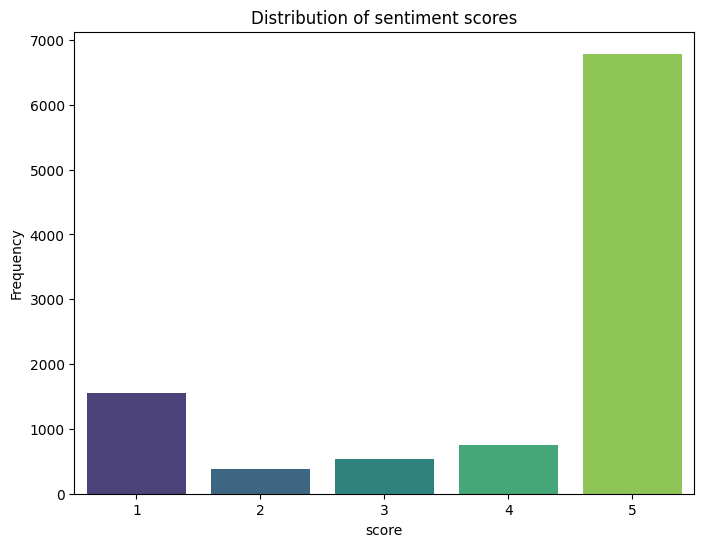

In [ ]:
# Basic EDA: Distribution of scores
plt.figure(figsize=(8, 6))
sns.countplot(data=data,x='score',palette='viridis')  #countplot is used to count value and then plot
plt.title("Distribution of sentiment scores")
plt.xlabel("score")
plt.ylabel("Frequency")
plt.show()

In [ ]:
#finding the percentage distribution of each score-- we'll divide the no of records for each rating by total no of records

print(f"Score value count- percentage distribution: \n{round(data['score'].value_counts()/data.shape[0]*100,2)}")

Score value count- percentage distribution: 
score
5    67.89
1    15.47
4     7.51
3     5.30
2     3.83
Name: count, dtype: float64


<Axes: ylabel='precentage wise distribution score'>

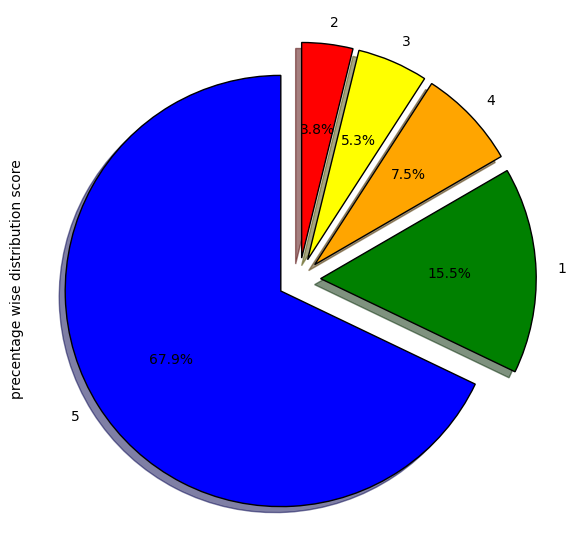

In [ ]:
#PIE CHART

fig=plt.figure(figsize=(7,7))

colors=('blue', 'green', 'orange', 'yellow', 'red')

wp={'linewidth':1, "edgecolor":'black'}

tags=data['score'].value_counts()/data.shape[0]

explode=(0.1,0.1,0.1,0.1,0.1)

tags.plot(kind='pie', autopct="%1.1f%%", shadow=True, colors=colors, startangle=90, wedgeprops=wp, explode=explode, label="precentage wise distribution score")


In [ ]:
print(f"Score value count- percentage distribution: \n{round(data['sentiment'].value_counts()/data.shape[0]*100,2)}")

Score value count- percentage distribution: 
sentiment
positive    75.4
negative    19.3
neutral      5.3
Name: count, dtype: float64


/tmp/ipykernel_5234/587533767.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data,x='score',palette='viridis')  #countplot is used to count value and then plot


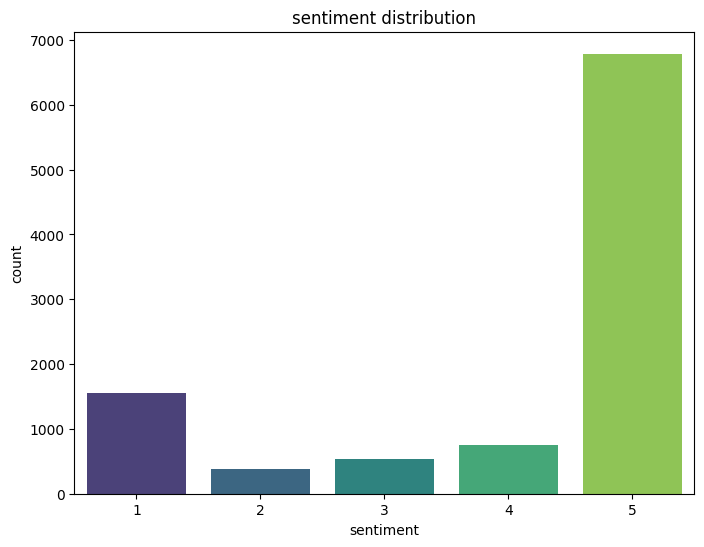

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=data,x='score',palette='viridis')  #countplot is used to count value and then plot
plt.title("sentiment distribution")
plt.xlabel("sentiment")
plt.ylabel("count")
plt.show()

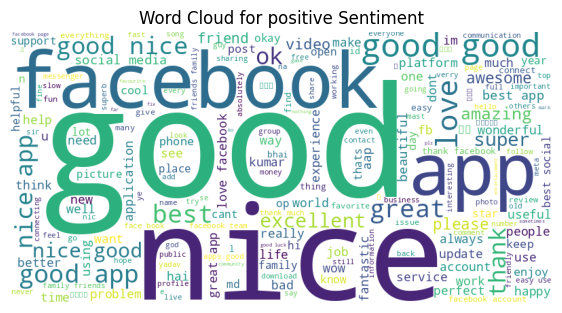

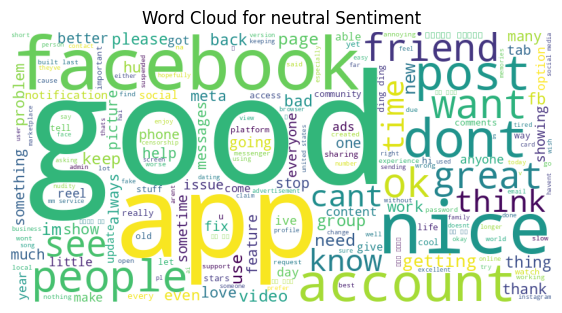

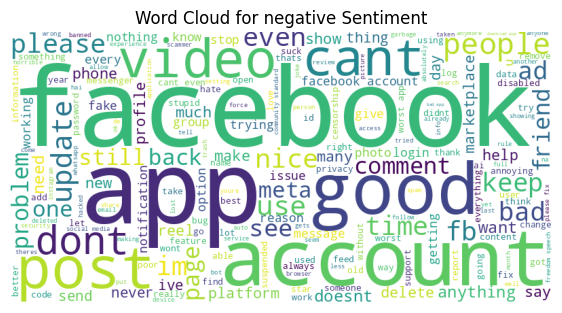

In [ ]:
#wordcloud---distribute words into psitive,negative and neutral

from wordcloud import WordCloud

for sentiment in data['sentiment'].unique():
  text=' '.join(data[data['sentiment']==sentiment]['cleaned_content'])
  wordcloud=WordCloud(width=800, height=400, background_color='white').generate(text)

  plt.figure(figsize=(7,5))
  plt.imshow(wordcloud)
  plt.title(f'Word Cloud for {sentiment} Sentiment')
  plt.axis('off')
  plt.show()


Feature Extraction

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

#convert text to TF-IDF features
tfidf=TfidfVectorizer(max_features=5000)
x=tfidf.fit_transform(data['cleaned_content']).toarray()
y=data['sentiment']


TRAIN/TEST SPLIT

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

#split data into training and testing sets
x_train,x_test,y_train,y_test= train_test_split(x,y, test_size=0.2, random_state=42)

TRAIN MULTIPLE MACHINE LEARNING MODELS

1.Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()
lr_model.fit(x_train, y_train)


LogisticRegression()

In [ ]:
#Logistic Regression
lr_preds=lr_model.predict(x_test)
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test,lr_preds))

Logistic Regression
Accuracy: 0.8125


2.NAIVE BAYES

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_model=MultinomialNB()
nb_model.fit(x_train,y_train)

MultinomialNB()

In [ ]:
#Naive Bayes
nb_preds=nb_model.predict(x_test)
print("\nNaive Bayes")
print("Accuracy:",accuracy_score(y_test,nb_preds))



Naive Bayes
Accuracy: 0.811


SVM

In [ ]:
from sklearn.svm import SVC    #Support Vector classifier

svm_model=SVC()
svm_model.fit(x_train, y_train)

SVC()

In [ ]:
#Support Vector Machine
svm_preds=svm_model.predict(x_test)
print("\nSupport Vector Machine")
print("Accuracy:",accuracy_score(y_test,svm_preds))



Support Vector Machine
Accuracy: 0.8095


Predict New Sentiments

In [ ]:
#sample new texts
new_texts=['I absolutely hate this!', 'This is the best experience ever.']

#Preprocess the texts
new_texts_cleaned=[preprocess_text(text) for text in new_texts]

#Transform to tf-idf
new_features=tfidf.transform(new_texts_cleaned).toarray()

#Predict using logistic regression
predictions=lr_model.predict(new_features)

#Print predictions
print(predictions)

['negative' 'positive']
